# Cholesky Method

In this notebook we simulate fBm paths using the cholesky decomposition. We start from scratch by demonstrating the Cholseky decomposition of multivariate Gaussian.

If $X$ is a multivariate Guassian distribution with $\mathbb{E}[X] = \mu$ and covariance matrix $\Sigma$ then if $\Sigma$ must be positive semi-definite, and hence we can write  it as a Cholesky decomposition $\Sigma = L L^T$ where $L$ is lower triangular. This allows us to simulate the multivariate distrubtion since if $Z = (Z_1, \dots , Z_n)$ is a standard multivariate Guassian then
$$ X = \mu + LZ$$

The following algorithm can be used to determine the cholesky decomposition for a given matrix. Note that the cost of this algorithm of the order $O(n^3)$.

In [2]:
import numpy as np

def cholesky_decomposition(A):
    """
    Perform Cholesky decomposition on a positive-definite matrix A.
    
    Parameters:
    A (numpy.ndarray): A positive-definite matrix.
    
    Returns:
    L (numpy.ndarray): A lower triangular matrix such that A = L @ L.T
    """
    n = A.shape[0]
    L = np.zeros_like(A)

    for i in range(n):
        for j in range(i + 1):
            if i == j:  # Diagonal elements
                L[i, j] = np.sqrt(A[i, i] - np.sum(L[i, :j] ** 2))
            else:  # Off-diagonal elements
                L[i, j] = (A[i, j] - np.sum(L[i, :j] * L[j, :j])) / L[j, j]

    return L

We now consider the $fBm_H$ which is a centred gaussian procces with $Cov(X_t,X_s) = \frac12[t^{2H} + s^{2H} - | t -s|^{2H}]$. Hence if we use $n$ time steps over a time intervals $T$ we can discretize on a time grid $\{0=t_0 < t_1 < \dots < t_n = T\} $ which then simply amounts to the simulation of the $(n+ 1)-$dimensional Gaussian random variable $X :=
(X_{t_0}, \dots , X_{t_n})$ which we discussed above.

In [ ]:
import numpy as np

H = 0.2
T = 10
N = 252
dt = T / N
t = np.linspace(0, T, N + 1)

Cov = np.zeros(shape = (N+1, N+1))
for i in range(N+1):
    for j in range(N+1):
        Cov[i, j] = 0.5*(t[i]**(2*H) + t[j]**(2*H) - abs(t[i] - t[j])**(2*H))
Cov += 1e-10 * np.eye(N + 1)  # Add a small value to the diagonal for numerical stability

L = cholesky_decomposition(Cov)

# Generate standard normal random variables
Z = np.random.randn(N + 1)
# Generate fractional Brownian motion
fBm = L @ Z
# fBm now contains the simulated fractional Brownian motion values at the specified time points 
print(fBm)

[-6.76193015e-04 -5.60315171e-01  3.58866101e-01  4.23606133e-01
  6.74328086e-01  3.82484581e-01  1.96877914e-01  8.08131904e-01
  4.43202044e-01  1.00021144e+00  8.00216057e-01  5.69090566e-01
  1.54903129e+00  1.11733424e+00  1.28085014e+00  8.98632923e-01
  2.39430573e+00  2.37370919e+00  2.10432735e+00  1.75750750e+00
  1.84852169e+00  1.06528770e+00  1.13817041e+00  6.95214334e-01
  1.17560918e+00  1.28455398e+00  1.65076401e+00  9.55013448e-01
  5.29731773e-01  3.44790058e-01  1.31029429e+00  5.30417638e-01
  9.26929687e-01  1.08121615e+00  1.47701489e+00  1.36638248e+00
  1.10078173e+00  1.60419821e+00  1.60682909e+00  1.33247705e+00
  1.44921288e+00  6.91857125e-01  8.14679640e-02  3.22162071e-01
  5.75236918e-01  7.12340528e-01  1.11934936e+00  1.29263736e+00
  9.12626241e-01  1.49448449e+00  7.71859770e-01  7.38743321e-01
  1.11063329e+00  1.73838958e+00  2.00814703e+00  2.36732843e+00
  2.23416695e+00  1.41612995e+00  8.79618612e-01  1.38160646e+00
  1.18311638e+00  1.81974

This algorithm for generating m samples paths of a Gaussian process on a grid of size n is of the
order $O(n^3) + m \times O(n^2)$ for $m$ sample paths.

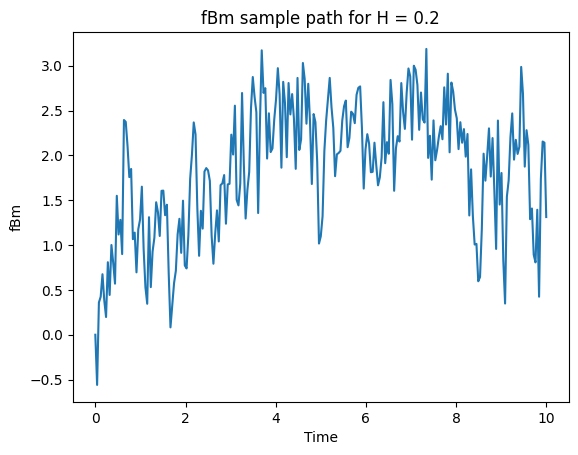

In [4]:
import matplotlib.pyplot as plt

plt.plot(t, fBm)
plt.title(f'fBm sample path for H = {H}') 
plt.xlabel('Time')
plt.ylabel('fBm')
plt.show()
